In [1]:
from tensorflow import keras
from keras import layers
import numpy as np
import pandas as pd

In [2]:
df = pd.DataFrame({
    'temperature': [10, 7, 4, 0],
    'sales': [30, 50, 60, 80]
})
df

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [3]:
# tensorflow는 2차원배열을 입력으로 받음
X = df[['temperature']].values.astype('float32')
y = df[['sales']].values.astype('float32')

# Dense(1) 은 입력값 1개 예측값 1개 선형 층 사실상 a * x + b
model = keras.Sequential([
    layers.Dense(1, input_shape=(1,))
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [4]:
# 모델 학습 방법 설정
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    loss='mse'
)

In [5]:
history = model.fit(
    X, y, epochs=10000, verbose=0
)


In [6]:
print('학습이 끝났습니다.')
print(f"마지막 epoch의 cost: {history.history['loss'][-1]:.4f}")

학습이 끝났습니다.
마지막 epoch의 cost: 4.3424


In [7]:
weight, bias = model.layers[0].get_weights()
a_value = weight[0][0]
b_value = bias[0]

print(f'학습된 기울기 a: {a_value:.4f}')
print(f'학습된 절편 b: {b_value:.4f}')

학습된 기울기 a: -4.8253
학습된 절편 b: 80.2948


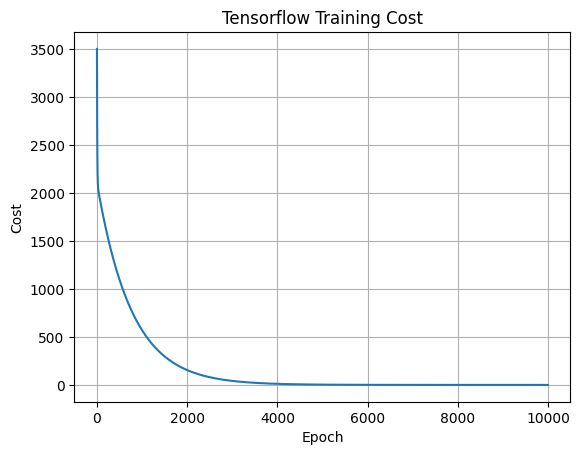

In [8]:
import matplotlib.pyplot as plt
cost_history = history.history['loss']
plt.figure()
plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Tensorflow Training Cost')
plt.grid(True)

1/1 [==============================] - 0s 48ms/step


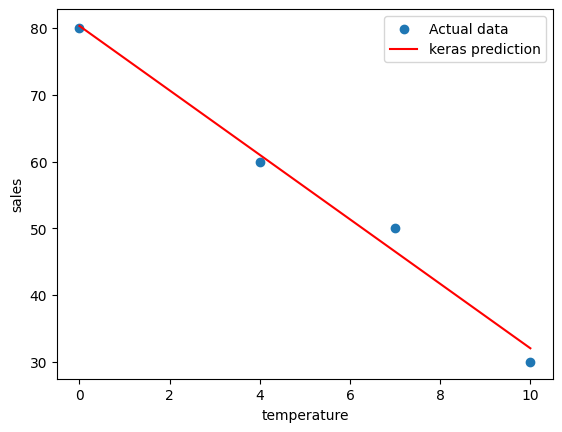

In [9]:
pred_y = model.predict(X)

plt.figure()
plt.scatter(X, y, label='Actual data')
plt.plot(X, pred_y, color='red', label='keras prediction')
plt.xlabel('temperature')
plt.ylabel('sales')
plt.legend()

In [10]:
new_temperature = np.array([[5]], dtype='float32')
pred_sales = model.predict(new_temperature)

print(f"기온이 5도일 때 예상 판매량: {pred_sales[0][0]:.2f}개")

1/1 [==============================] - 0s 9ms/step
기온이 5도일 때 예상 판매량: 56.17개
